### `Command`를 활용한 고급 흐름 제어

<br>

#### `Command`
- `Command`는 LangGraph에서 **"다음에 어디로 갈지"와 "상태를 어떻게 바꿀지"를 한 번에 결정**할 수 있는 혁신적인 기능으로, 기존 조건부 엣지의 한계를 뛰어넘어 더욱 유연한 워크플로우 제어를 가능
  - 이는 복잡한 비즈니스 로직을 보다 쉽고 효율적으로 구현할 수 있는 핵심 도구
- `Command`의 핵심 가치는 **원자적 연산(Atomic Operation)**
  - 전통적인 방식에서는 라우팅 결정과 상태 업데이트가 별도의 단계로 분리되어 있어 중간 상태의 불일치나 복잡한 동기화 문제가 발생할 수 있었지만, 
    
    `Command`는 이 두 작업을 하나의 원자적 연산으로 통합하여 데이터 일관성을 보장하고 시스템의 안정성을 크게 향상
    
    - 예) 쇼핑몰 주문 처리 시스템에서 재고 확인 결과에 따라 다른 경로로 분기하면서 동시에 고객에게 보여줄 메시지를 업데이트하고, 주문 상태를 변경하고, 로그를 기록하는 등의 복잡한 작업을 하나의 `Command`로 처리
  
    $\rightarrow$ 코드의 간결성뿐만 아니라 비즈니스 로직의 명확성도 크게 향상

<br>

#### 기본 `Command` 사용 (간단한 쇼핑몰 주문 처리)
- `Command`의 핵심 기능
  - `goto` : 다음에 실행할 노드 지정
  - `update` : 상태 업데이트

In [1]:
from typing import Literal
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command
from typing import TypedDict
from visualize_graph import visualize_graph

In [67]:
class OrderState(TypedDict):
    customer_name: str
    item: str
    quantity: int
    price: float
    status: str
    messages: list

- 노드 정의
  - `check_inventory`는 재고를 확인하고, 결과에 따라 다른 경로로 보내는 동시에 상태를 업데이트
  - `Command(goto="process_payment", update={...})` "결제 처리로 가면서 동시에 상태 메시지 업데이트"를 한 번에 수행
    
    재고가 있으면 결제로, 없으면 품절 처리로 자동 분기

In [68]:
def check_inventory(state: OrderState) -> Command[Literal["process_payment", "out_of_stock", END]]:
    """재고 확인 후 다음 단계 결정"""
    item = state["item"]
    quantity = state["quantity"]

    # 간단한 재고 확인 (실제로는 DB 조회)
    available_stock = {"사과": 10, "바나나": 5, "오렌지": 0}
    stock = available_stock.get(item, 0)

    if stock >= quantity:
        # 재고 충분 - 결제 처리로 이동
        return Command(
            goto="process_payment",
            update={
                "status": "재고 확인 완료",
                "messages": state["messages"] + [f"{item} {quantity}개 재고 확인됨"]
            }
        )
    else:
        # 재고 부족 - 품절 처리로 이동
        return Command(
            goto="out_of_stock",
            update={
                "status": "재고 부족",
                "messages": state["messages"] + [f"{item} 재고 부족 (요청: {quantity}개, 보유: {stock}개)"]
            }
        )

In [69]:
def process_payment(state: OrderState) -> Command[Literal["send_confirmation", END]]:
    """결제 처리"""
    total_price = state["quantity"] * state["price"]

    return Command(
        goto="send_confirmation",
        update={
            "status": "결제 완료",
            "messages": state["messages"] + [f"결제 완료: {total_price}원"]
        }
    )

In [70]:
def out_of_stock(state: OrderState) -> Command[Literal[END]]:
    """품절 처리"""
    return Command(
        goto=END,
        update={
            "status": "주문 취소됨",
            "messages": state["messages"] + ["죄송합니다. 품절로 인해 주문이 취소되었습니다."]
        }
    )

In [71]:
def send_confirmation(state: OrderState) -> Command[Literal[END]]:
    """주문 확인 메시지 발송"""
    customer = state["customer_name"]

    return Command(
        goto=END,
        update={
            "status": "주문 완료",
            "messages": state["messages"] + [f"{customer}님께 주문 확인 메시지를 발송했습니다."]
        }
    )

- 그래프 정의

In [75]:
order_graph = StateGraph(OrderState)
order_graph.add_node("check_inventory", check_inventory)
order_graph.add_node("process_payment", process_payment)
order_graph.add_node("out_of_stock", out_of_stock)
order_graph.add_node("send_confirmation", send_confirmation)

order_graph.add_edge(START, "check_inventory")
order_app = order_graph.compile()

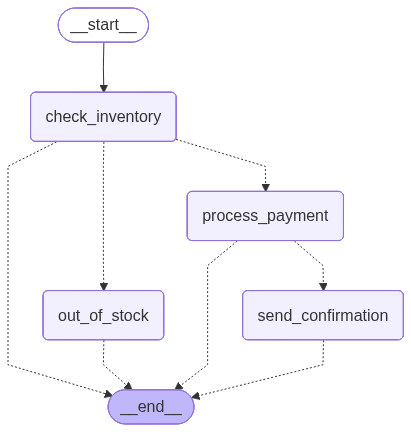

In [77]:
visualize_graph(order_app)

<br>

- 코드 실행 결과

In [78]:
print("=== 쇼핑몰 주문 처리 ===")

# 성공 케이스
success_result = order_app.invoke({
    "customer_name": "김철수",
    "item": "사과",
    "quantity": 3,
    "price": 1000,
    "status": "",
    "messages": []
})

print(f"고객: {success_result['customer_name']}")
print(f"최종 상태: {success_result['status']}")
print("처리 과정:")
for msg in success_result['messages']:
    print(f"  - {msg}")

print("\n" + "="*50 + "\n")

=== 쇼핑몰 주문 처리 ===
고객: 김철수
최종 상태: 주문 완료
처리 과정:
  - 사과 3개 재고 확인됨
  - 결제 완료: 3000원
  - 김철수님께 주문 확인 메시지를 발송했습니다.




In [80]:
# 실패 케이스 (품절)
fail_result = order_app.invoke({
    "customer_name": "이영희",
    "item": "오렌지",
    "quantity": 2,
    "price": 1500,
    "status": "",
    "messages": []
})

print(f"고객: {fail_result['customer_name']}")
print(f"최종 상태: {fail_result['status']}")
print("처리 과정:")
for msg in fail_result['messages']:
    print(f"  - {msg}")

고객: 이영희
최종 상태: 주문 취소됨
처리 과정:
  - 오렌지 재고 부족 (요청: 2개, 보유: 0개)
  - 죄송합니다. 품절로 인해 주문이 취소되었습니다.


<br>

#### 조건부 엣지 vs `Command`
- **조건부 엣지는 '어디로 갈지'만 결정하고, 상태 변경은 도착한 노드에서 처리**
- **`Command`는 어디로 가면서 동시에 상태를 어떻게 바꿀지 함꼐 결정**

<br>

- **Command를 사용하면 좋은 경우:**
  - 다음 단계로 가면서 동시에 여러 상태를 업데이트해야 할 때
  - 재시도나 복구 로직이 복잡한 경우
  - 동적으로 조건을 판단하여 다른 경로로 보내야 할 때
  - 비즈니스 로직이 복잡하고 여러 요소를 동시에 고려해야 할 때
  - 서브그래프에서 부모 그래프로 제어를 이동해야 할 때
  - 도구 실행 결과로 그래프 상태를 업데이트해야 할 때
  - Human-in-the-Loop에서 사용자 입력으로 실행을 재개할 때

<br>

- **조건부 엣지를 사용하면 좋은 경우:**
    - 간단한 분기만 필요한 경우
    - 라우팅 로직과 비즈니스 로직을 명확히 분리하고 싶은 경우
    - 여러 노드로 병렬 실행이 필요한 경우

In [82]:
class StudentState(TypedDict):
    name: str
    score: int
    grade: str
    feedback: str
    retry_count: int

- **조건부 엣지 방식**
  - 조건만 판단하는 노드와, 상태를 업데이트하는 노드 별도 필요

In [83]:
def evaluate_score_traditional(state: StudentState) -> dict:
    """전통적인 방식 - 점수만 평가"""
    score = state["score"]

    if score >= 90:
        grade = "A"
    elif score >= 80:
        grade = "B"
    elif score >= 70:
        grade = "C"
    else:
        grade = "F"

    return {"grade": grade}

def route_by_grade(state: StudentState) -> Literal["excellent", "good", "average", "need_help"]:
    """조건부 엣지용 라우터"""
    grade = state["grade"]
    if grade == "A":
        return "excellent"
    elif grade == "B":
        return "good"
    elif grade == "C":
        return "average"
    else:
        return "need_help"

<br>

- **`Command` 방식** : 평가와 동시에 피드백까지 생성
  - `need_help_handler` : 재시험 기회를 제공하며, 점수를 향상시켜 다시 평가

In [85]:
def evaluate_score_smart(state: StudentState) -> Command[Literal["excellent", "good", "average", "need_help", END]]:
    """Command 방식 - 평가와 동시에 피드백까지 생성"""
    score = state["score"]
    name = state["name"]
    retry_count = state.get("retry_count", 0)

    if score >= 90:
        return Command(
            goto="excellent",
            update={
                "grade": "A",
                "feedback": f"{name}님, 훌륭합니다! {score}점은 정말 대단해요!",
                "retry_count": 0  # 성공하면 재시도 카운트 리셋
            }
        )
    elif score >= 80:
        return Command(
            goto="good",
            update={
                "grade": "B",
                "feedback": f"{name}님, 잘했어요! {score}점이네요.",
                "retry_count": 0
            }
        )
    elif score >= 70:
        return Command(
            goto="average",
            update={
                "grade": "C",
                "feedback": f"{name}님, 괜찮아요. {score}점입니다.",
                "retry_count": retry_count
            }
        )
    else:
        # F학점이면서 재시도가 3번 미만이면 재도전 기회 제공
        if retry_count < 3:
            return Command(
                goto="need_help",
                update={
                    "grade": "F",
                    "feedback": f"{name}님, 다시 도전해보세요! (재시도 {retry_count + 1}/3)",
                    "retry_count": retry_count + 1
                }
            )
        else:
            return Command(
                goto=END,
                update={
                    "grade": "F",
                    "feedback": f"{name}님, 추가 도움이 필요해 보입니다. 선생님과 상담하세요.",
                    "retry_count": retry_count
                }
            )

def excellent_handler_smart(state: StudentState):
    print(f"--- Excellent Node: {state['name']} ---")
    return Command(
        update={"feedback": state["feedback"] + " 상장을 받으세요!"},
        goto=END
    )
    
def common_handler_smart(state: StudentState):
    print(f"--- General Feedback Node ---")
    return Command(goto=END)

def need_help_handler(state: StudentState) -> Command[Literal["evaluate_score_smart", END]]:
    """도움이 필요한 학생 처리"""
    retry_count = state["retry_count"]

    if retry_count < 3:
        return Command(
            goto="evaluate_score_smart",
            update={
                "score": state["score"] + 10,  # 도움을 받아 점수 향상
                "feedback": state["feedback"] + " 추가 공부 후 재시험!"
            }
        )
    else:
        return Command(goto=END, update={})

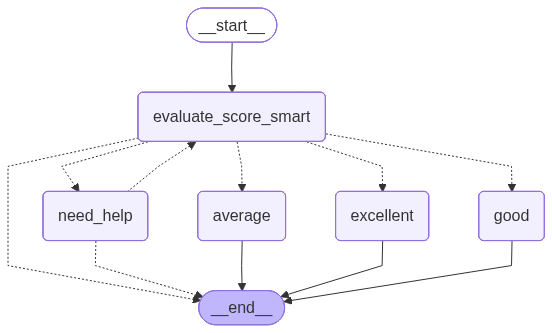

In [86]:
smart_builder = StateGraph(StudentState)

smart_builder.add_node("evaluate_score_smart", evaluate_score_smart)
smart_builder.add_node("excellent", excellent_handler_smart)
smart_builder.add_node("good", common_handler_smart)
smart_builder.add_node("average", common_handler_smart)
smart_builder.add_node("need_help", need_help_handler)

smart_builder.add_edge(START, "evaluate_score_smart")

smart_app = smart_builder.compile()
visualize_graph(smart_app)

<br>

#### `Command.PARENT` : 서브그래프에서 부모로 이동
- **서브그래프 내의 노드에서 부모 그래프의 다른 노드로 직접 이동해야 하는 경우, `Command.PARENT`를 사용**
  - 이 패턴은 멀티 에이전트 시스템에서 에이전트 간 핸드오프(handoff)를 구현할 때 유용

In [96]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.types import Command
from typing import TypedDict, Literal, Annotated

- 상태 정의
  - **부모와 서브그래프가 공유하는 상태 키(예: `messages`)에 대해서는 반드시 `reducer`를 정의**

In [97]:
class ParentState(TypedDict):
    messages: Annotated[list[str], add_messages]
    status: str

class ChildState(TypedDict):
    messages: Annotated[list[str], add_messages]
    task: str

- 서브그래프 노드
  - **`graph=Command.PARENT`를 설정하면 현재 서브그래프에서 가장 가까운 부모 그래프로 제어가 이동**

In [98]:
def child_node(state: ChildState) -> Command[Literal[END]]:
    """서브그래프에서 작업 후 부모 그래프로 제어 이동"""
    task = state.get("task", "normal")

    if task == "escalate":
        # 런타임에 부모 노드로 이동
        return Command(
            goto="parent_handler", 
            graph=Command.PARENT,   
            update={
                "messages": [f"서브그래프에서 에스컬레이션: {task}"]
            }
        )
    else:
        return Command(
            goto=END,
            update={
                "messages": [f"서브그래프에서 처리 완료: {task}"]
            }
        )

- 서브그래프 정의 및 컴파일

In [99]:
child_builder = StateGraph(ChildState)
child_builder.add_node("child_node", child_node)
child_builder.add_edge(START, "child_node")
child_graph = child_builder.compile()

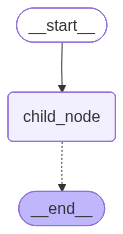

In [100]:
visualize_graph(child_graph)

<br>

- 부모 그래프 노드

In [101]:
def parent_start(state: ParentState) -> dict:
    return {"messages": ["부모 그래프 시작"]}

def parent_handler(state: ParentState) -> dict:
    print("--- Parent Handler Executed ---")
    return {
        "messages": ["부모에서 에스컬레이션 처리 완료"],
        "status": "escalated"
    }

- 부모 그래프 정의

In [102]:
parent_builder = StateGraph(ParentState)
parent_builder.add_node("start", parent_start)
parent_builder.add_node("child", child_graph) 
parent_builder.add_node("parent_handler", parent_handler)

parent_builder.add_edge(START, "start")
parent_builder.add_edge("start", "child")

parent_builder.add_edge("child", END) 
parent_builder.add_edge("parent_handler", END)

parent_app = parent_builder.compile()

<br>

<img src='img/1-6-1.png' width=200>

<br>

#### 도구(Tool)내에서 Command 사용
- **도구 내 에서 그래프 상태를 업데이트해야 하는 경우**
- 도구에서 `Command`를 반환할 때는 `LangGraph`의 `ToolNode`를 사용하는 것이 바람직
  - `ToolNode`는 도구가 반환하는 `Command` 객체를 자동으로 처리하고 그래프 상태에 전파
- 커스텀 노드에서 도구를 직접 호출하는 경우, `Command` 객체를 수동으로 전파해야 함

In [104]:
from langchain.tools import tool
from langgraph.types import Command
from langgraph.prebuilt import ToolNode
from langchain_core.messages import ToolMessage

In [105]:
@tool
def lookup_customer(account_id: str) -> Command:
    """고객 정보를 조회하고 그래프 상태를 업데이트합니다."""
    # 실제로는 DB에서 고객 정보 조회
    customer_data = {
        "ACC001": {"name": "김철수", "tier": "VIP", "balance": 1000000},
        "ACC002": {"name": "이영희", "tier": "Regular", "balance": 50000},
    }

    customer = customer_data.get(account_id)

    if customer:
        # 도구에서 Command를 반환하여 상태 업데이트
        return Command(
            update={
                "customer_info": customer,
                "messages": [
                    ToolMessage(
                        content=f"고객 정보 조회 완료: {customer['name']} ({customer['tier']})",
                        tool_call_id="lookup"  # 실제로는 동적으로 할당
                    )
                ]
            }
        )
    else:
        return Command(
            update={
                "messages": [
                    ToolMessage(
                        content=f"계정 {account_id}를 찾을 수 없습니다.",
                        tool_call_id="lookup"
                    )
                ]
            }
        )

<br>

#### Human-in-the-Loop과 `Command(resume=...)`
- **`interrupt()`함수로 실행을 일시 중지한 후, `Command(resume=...)`를 사용하여 사용자 입력과 함께 실행을 재개할 수 있음**


In [106]:
from langgraph.types import Command, interrupt
from langgraph.checkpoint.memory import InMemorySaver

- 상태 정의

In [107]:
class ReviewState(TypedDict):
    document: str
    review_result: str
    approved: bool

- 노드 함수

In [108]:
def human_review_node(state: ReviewState) -> dict:
    """문서 검토를 위해 인간의 입력을 대기"""
    document = state["document"]

    # 실행 일시 중지 - 인간의 검토 대기
    human_input = interrupt({
        "task": "document_review",
        "document": document,
        "options": ["approve", "reject", "revise"]
    })

    # 재개 시 human_input에는 Command(resume=...)의 값이 들어옴
    return {
        "review_result": human_input.get("decision", "pending"),
        "approved": human_input.get("decision") == "approve"
    }

- 그래프 설정

In [111]:
review_graph = StateGraph(ReviewState)
review_graph.add_node("review", human_review_node)
review_graph.add_edge(START, "review")
review_graph.add_edge("review", END)

<br>

- **`checkpointer`와 함께 컴파일**

In [112]:
checkpointer = InMemorySaver()
review_app = review_graph.compile(checkpointer=checkpointer)

<br>

- 실행
    1. `invoke()`로 그래프 실행 시작
    2. `interrupt()`에서 실행이 일시 중지되고 상태가 체크포인트에 저장
    3. 인간이 검토 후 `Command(resume=...)`와 함께 다시 `invoke()` 호출
    4. `interrupt()` 지점에서 재개되며, `resume` 값이 `human_input`에 전달

In [119]:
config = {"configurable": {"thread_id": "review-123"}}
result = review_app.invoke({"document": "분기별 보고서 초안"}, config)

In [120]:
result

{'document': '분기별 보고서 초안',
 'review_result': 'approve',
 'approved': True,
 '__interrupt__': [Interrupt(value={'task': 'document_review', 'document': '분기별 보고서 초안', 'options': ['approve', 'reject', 'revise']}, id='ff60df0b2f9e1feb5d843d0e0b92633d')]}

- 인간이 검토 후 재개

In [ ]:
resume_result = review_app.invoke(
    Command(resume={"decision": "approve", "comment": "좋습니다!"}),
    config
)

print(f"검토 결과: {resume_result['review_result']}")
print(f"승인 여부: {resume_result['approved']}")

검토 결과: approve
승인 여부: True


In [122]:
resume_result

{'document': '분기별 보고서 초안', 'review_result': 'approve', 'approved': True}

<br>

### Send API - 동적 병렬 실행
- **`send`는 조건부 엣지에서 반환하여, 동적으로 노드를 호출하고, 각 호출에 다른 상태를 전달할 수 있게 해주는 객체**

<br>

#### `Send`의 사용
- **Map-Reduce 패턴** : 첫 노드가 객체 리스트를 생성하고, 각 객체에 다른 노드를 적용해야 할 때
- **동적 분기** : 런타임에 분기 수가 결정되는 경우
- **병렬 처리** : 동일한 노드를 여러 다른 입력으로 동시에 실행해야 할 때

<br>

#### 사용
- **`Send`는 두 개의 인자가 필요**
  - **노드 이름** : 실행할 노드
  - **상태** : 해당 노드에 전달할 상태

In [2]:
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from operator import add

- 상태 정의

In [3]:
class OverallState(TypedDict):
    topics: list[str]
    summaries: Annotated[list[str], add]

In [4]:
class TopicState(TypedDict):
    topic: str

- 노드 함수
  - `route_to_summarizers`는 `Send` 객체 리스트를 반환

In [5]:
def generate_topics(state: OverallState) -> dict:
    """주제 리스트 생성"""
    return {
        "topics": ["AI의 역사", "머신러닝 기초", "딥러닝 응용"]
    }

In [ ]:
def route_to_summarizers(state: OverallState) -> list[Send]:
    """각 주제에 대해 Send 객체 생성 - 동적 병렬 분기"""
    return [
        Send("summarize_topic", {"topic": topic}) for topic in state["topics"]
    ]

In [7]:
def summarize_topic(state: TopicState) -> dict:
    """개별 주제 요약 (병렬 실행됨)"""
    topic = state["topic"]
    # 실제로는 LLM 호출
    summary = f"{topic}에 대한 요약입니다."
    return {"summaries": [summary]}

- 그래프 정의
  - 조건부 엣지에서 `Send` 리스트 반환
  - 각 `Send`는 `summarize_topic` 노드를 다른 상태(topic)로 호출
  - 모든 `summarize_topic` 노드가 병렬로 실행됨
  - `summaries`에는 `add reducer`가 있어 결과가 자동 병합

In [ ]:
builder = StateGraph(OverallState)
builder.add_node("generate_topics", generate_topics)
builder.add_node("summarize_topic", summarize_topic)

builder.add_edge(START, "generate_topics")

# 조건부 엣지에서 Send 리스트 반환
builder.add_conditional_edges("generate_topics", route_to_summarizers)
builder.add_edge("summarize_topic", END)

graph = builder.compile()

- 실행

In [10]:
result = graph.invoke({"topics": [], "summaries": []})
print(result["summaries"])

['AI의 역사에 대한 요약입니다.', '머신러닝 기초에 대한 요약입니다.', '딥러닝 응용에 대한 요약입니다.']


<br>

#### Map-Reduce 패턴 구형
- Send API를 활용한 Map-Reduce 패턴

In [13]:
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from operator import add

- 상태 정의

In [14]:
class MapReduceState(TypedDict):
    documents: list[str]
    processed_results: Annotated[list[dict], add]
    final_summary: str

In [15]:
class DocumentState(TypedDict):
    document: str
    doc_index: int

- 노드 함수

In [16]:
def load_documents(state: MapReduceState) -> dict:
    """문서 로드"""
    return {
        "documents": [
            "첫 번째 문서 내용...",
            "두 번째 문서 내용...",
            "세 번째 문서 내용...",
        ]
    }

In [ ]:
def map_documents(state: MapReduceState) -> list[Send]:
    """MAP 단계: 각 문서에 대해 병렬 처리 노드 생성"""
    return [
        Send("process_document", {
            "document": doc,
            "doc_index": i
        }) for i, doc in enumerate(state["documents"])
    ]

In [18]:
def process_document(state: DocumentState) -> dict:
    """개별 문서 처리 (병렬 실행)"""
    doc = state["document"]
    idx = state["doc_index"]

    # 실제로는 문서 분석, 요약, 키워드 추출 등
    result = {
        "index": idx,
        "word_count": len(doc.split()),
        "summary": f"문서 {idx + 1} 처리 완료"
    }

    return {"processed_results": [result]}

In [19]:
def reduce_results(state: MapReduceState) -> dict:
    """REDUCE 단계: 모든 결과 집계"""
    results = state["processed_results"]
    total_words = sum(r["word_count"] for r in results)
    summaries = [r["summary"] for r in results]

    return {
        "final_summary": f"총 {len(results)}개 문서, {total_words} 단어 처리"
    }

- 그래프 구성

In [20]:
builder = StateGraph(MapReduceState)
builder.add_node("load", load_documents)
builder.add_node("process_document", process_document)
builder.add_node("reduce", reduce_results)

builder.add_edge(START, "load")
builder.add_conditional_edges("load", map_documents)
builder.add_edge("process_document", "reduce")
builder.add_edge("reduce", END)

mr_graph = builder.compile()

- 실행

In [23]:
result = mr_graph.invoke({
    "documents": [],
    "processed_results": [],
    "final_summary": ""
})

print(result["final_summary"])

총 3개 문서, 12 단어 처리


<br>

### `Send`와 `Command` 차이

<table>
<thead>
<tr>
<th>특성</th>
<th>Send</th>
<th>Command</th>
</tr>
</thead>
<tbody>
<tr>
<td><strong>목적</strong></td>
<td>동적 병렬 분기</td>
<td>라우팅 + 상태 업데이트</td>
</tr>
<tr>
<td><strong>반환 위치</strong></td>
<td>조건부 엣지 함수</td>
<td>노드 함수</td>
</tr>
<tr>
<td><strong>상태 전달</strong></td>
<td>각 분기에 다른 상태</td>
<td>동일 그래프 상태 업데이트</td>
</tr>
<tr>
<td><strong>실행 방식</strong></td>
<td>모든 Send가 병렬 실행</td>
<td>단일 경로 이동</td>
</tr>
<tr>
<td><strong>사용 사례</strong></td>
<td>Map-Reduce, 배치 처리</td>
<td>조건부 라우팅, 핸드오프</td>
</tr>
</tbody>
</table>

<br>

<hr>